$$\text{SIM ID: 10263704 }$$
$$\text{NAME: Subathra Sundarbabu}$$
$$\text{DATE: 7 Jan 2026}$$
$$\text{CM3015 Machine Learning and Neural Networks}$$

<h3 style="text-align:center;">Comparing Supervised Models and the Impact of PCA Dimensionality Reduction (Wine Dataset)</h3>

# 1 Introduction

By identifying patterns in numerical features, machine learning techniques are often used to classify data. Each sample in this project represents a wine that is defined by a collection of chemical measures, and the Wine dataset is used to look at a supervised classification problem. The aim of this project is to use a consistent evaluation approach to compare the performance of various supervised machine learning algorithms on the same dataset. Additionally, Principal Component Analysis (PCA) is used to investigate whether lowering the data's dimensionality has an impact on interpretability and classification performance. At least one algorithm must be constructed from scratch in order to fulfill the coursework requirements, and common evaluation methods including train-test splitting, feature scaling, and cross-validation are applied. 

# 2 Dataset Description

The Wine dataset used for this project is described in this section (scikit-learn, 2024). This section's goal is to examine the dataset before any modeling or preparation is done. In particular, the dataset size, data types, and dataset origin are analysed to verify that the data is already supplied in a vectorized numerical format and is appropriate for supervised machine learning.

## 2.1 Size

The size of the dataset is seen in this section. Because it affects model complexity, overfitting risk, and evaluation technique selection, it is important to understand the number of samples and features.

In [1]:
# Import the Wine dataset
from sklearn.datasets import load_wine

In [2]:
# Load the Wine dataset
wine = load_wine()

In [3]:
# Store the feature matrix in x
X = wine.data

In [4]:
# Print the results
print("rows:", X.shape[0])
print("columns:", X.shape[1])

rows: 178
columns: 13


Each of the 178 samples in the Wine dataset has 13 numerical characteristics. This dataset size allows for effective experimentation while lowering the possibility of excessive processing cost, making it appropriate for traditional supervised learning methods. The dataset is suitable for applying PCA to analyse the impact of dimensionality reduction due to its moderate feature count.

## 2.2 Data types

The data types and dataset structure are looked at in this section. It is important to ensure that all features are numerical and that the goal variable is accurately represented as class labels because machine learning algorithms require numerical inputs.

In [5]:
# Import required library
import pandas as pd

In [6]:
# Convert the feature matrix into df
df = pd.DataFrame(X, columns=wine.feature_names)

In [7]:
# store the target in a target column
df["target"] = wine.target

In [8]:
# first 5 rows of the df
df.head()

,alcohol,malic_acid,ash,alcalinity_of_ash,magnesium,total_phenols,flavanoids,nonflavanoid_phenols,proanthocyanins,color_intensity,hue,od280/od315_of_diluted_wines,proline,target
0,14.23,1.71,2.43,15.6,127.0,2.80,3.06,0.28,2.29,5.64,1.04,3.92,1065.0,0
1,13.20,1.78,2.14,11.2,100.0,2.65,2.76,0.26,1.28,4.38,1.05,3.40,1050.0,0
2,13.16,2.36,2.67,18.6,101.0,2.80,3.24,0.30,2.81,5.68,1.03,3.17,1185.0,0
3,14.37,1.95,2.50,16.8,113.0,3.85,3.49,0.24,2.18,7.80,0.86,3.45,1480.0,0
4,13.24,2.59,2.87,21.0,118.0,2.80,2.69,0.39,1.82,4.32,1.04,2.93,735.0,0


In [9]:
# Check the columns currently have in the df
print(df.columns)

Index(['alcohol', 'malic_acid', 'ash', 'alcalinity_of_ash', 'magnesium',
       'total_phenols', 'flavanoids', 'nonflavanoid_phenols',
       'proanthocyanins', 'color_intensity', 'hue',
       'od280/od315_of_diluted_wines', 'proline', 'target'],
      dtype='object')


In [10]:
# the types of data of the different columns
df.dtypes

alcohol                         float64
malic_acid                      float64
ash                             float64
alcalinity_of_ash               float64
magnesium                       float64
total_phenols                   float64
flavanoids                      float64
nonflavanoid_phenols            float64
proanthocyanins                 float64
color_intensity                 float64
hue                             float64
od280/od315_of_diluted_wines    float64
proline                         float64
target                            int32
dtype: object

The Wine dataset's feature columns are all of type float64, which means continuous numerical values that are appropriate for machine learning models. The target column is in int32. All inputs are already in a fully quantitative, vectorized format, and the dataset lacks any text-based or categorical features. This verifies that preprocessing, scaling, and model training do not need any further encoding or data type conversion.

## 2.3 Origin

The scikit-learn machine learning offers a pre-built dataset called the Wine dataset. It comes from a chemical analysis of wines produced in the same area but from different varieties, and it is frequently used for benchmarking and teaching purposes. No external data sourcing or manual preprocessing was needed before to analysis because the dataset is directly accessible within the library.

# 3 Data Preprocessing

This section examines the dataset for null or missing values. Verifying whether imputation or removal is necessary is important since missing values can lead to errors or bias during model training.

## 3.1 Checking Null values

In [11]:
# checking the null values in the columns
df.isna().sum()

alcohol                         0
malic_acid                      0
ash                             0
alcalinity_of_ash               0
magnesium                       0
total_phenols                   0
flavanoids                      0
nonflavanoid_phenols            0
proanthocyanins                 0
color_intensity                 0
hue                             0
od280/od315_of_diluted_wines    0
proline                         0
target                          0
dtype: int64

None of the feature columns had null or missing values, according to the missing value check. This tells that the dataset can now be used directly for analysis and modeling without the need for imputation or data removal.

## 3.2 Range Checks

This section examines summary statistics for each feature in order to conduct a basic integrity check. This helps in seeing any unexpected values, such as abnormal severe ranges or negative values where they should not be.

In [12]:
# count, mean, standard deviation, min, and max
df.describe().T

,count,mean,std,min,25%,50%,75%,max
alcohol,178.0,13.000618,0.811827,11.03,12.3625,13.050,13.6775,14.83
malic_acid,178.0,2.336348,1.117146,0.74,1.6025,1.865,3.0825,5.80
ash,178.0,2.366517,0.274344,1.36,2.2100,2.360,2.5575,3.23
alcalinity_of_ash,178.0,19.494944,3.339564,10.60,17.2000,19.500,21.5000,30.00
magnesium,178.0,99.741573,14.282484,70.00,88.0000,98.000,107.0000,162.00
total_phenols,178.0,2.295112,0.625851,0.98,1.7425,2.355,2.8000,3.88
flavanoids,178.0,2.029270,0.998859,0.34,1.2050,2.135,2.8750,5.08
nonflavanoid_phenols,178.0,0.361854,0.124453,0.13,0.2700,0.340,0.4375,0.66
proanthocyanins,178.0,1.590899,0.572359,0.41,1.2500,1.555,1.9500,3.58
color_intensity,178.0,5.058090,2.318286,1.28,3.2200,4.690,6.2000,13.00


All features have accurate numerical values with consistent counts across all variables, according to the summary statistics, indicating that there are no missing data points. No excessive values are found, and the feature ranges seem appropriate for chemical measurements. For a three-class classification task, the goal variable is expressed as integer class labels with values between 0 and 2. Before moving on to exploratory data analysis, the dataset shows good data integrity overall and does not require any additional cleaning.

# 4 Visualisations

The Wine dataset is seen in this part through visualisation. Without using any modeling, exploratory data analysis aims to give a better understanding of class distribution, feature behaviour, and correlations between variables. Later decisions during model building and evaluation are made by the analysis seen here.

## 4.1 Class Distribution

The distribution of the samples among the three wine classes is looked at in this section. Because highly unbalanced classes can skew model performance and evaluation measures, it is important to understand class distribution.

In [13]:
# Import required library
import matplotlib.pyplot as plt

In [14]:
# Convert target labels into a pandas Series
countclass = pd.Series(df["target"]).value_counts().sort_index()

In [15]:
# Print the number of samples in each class
print(countclass)

target
0    59
1    71
2    48
Name: count, dtype: int64


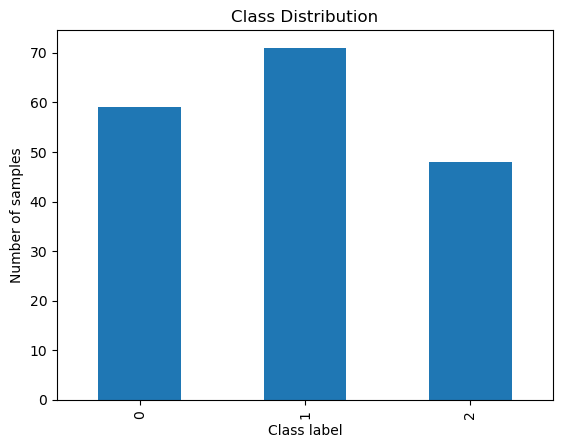

In [16]:
# Plot the class distribution
countclass.plot(kind="bar")
plt.xlabel("Class label")
plt.ylabel("Number of samples")
plt.title("Class Distribution")
plt.show()

The Wine dataset have three classes with varying sample sizes, as the bar chart shows. Class 2 has the fewest samples, Class 0 comes in second, and Class 1 has the most. The degree of imbalance is mild rather than severe, despite the fact that the classes are not fully balanced. This distribution works well for supervised classification, particularly when cross-validation and stratified train-test splitting are used to ensure equal evaluation for every class.

## 4.2 Feature Distribution Boxplot

This section uses boxplots to show the distribution of individual features. Boxplots are useful for comparing median values, feature spread, and the presence of possible outliers across various variables.

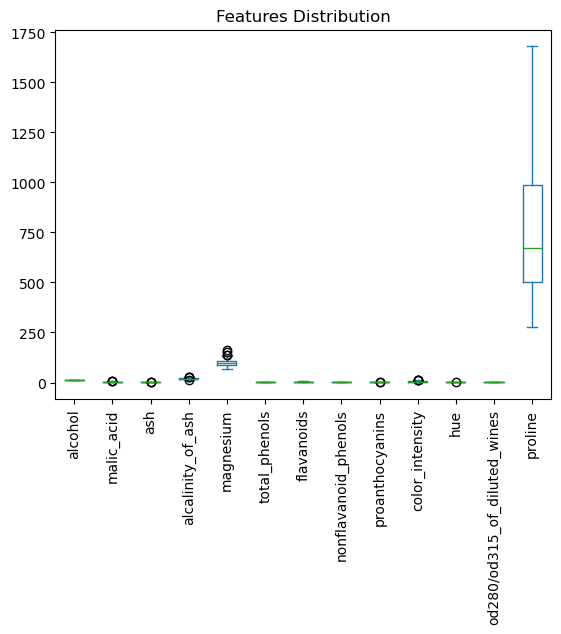

In [17]:
# boxplots for feature columns
df.drop(columns=["target"]).plot(kind="box",rot=90)
plt.title("Features Distribution")
plt.show()

The boxplot visualisation shows significant variations in scale and variability among the features. When compared to other variables, the proline feature shows a significantly wider range and spread, whereas other features are closely grouped around smaller values. Different spreads and a few obvious outliers tells that the dataset's raw feature magnitudes differs. These findings support the importance of feature scaling before using PCA and distance-based models in the model-building.

## 4.3 Feature Correlation Heatmap

This section uses a heatmap to show the relationship between numerical features. Finding links and redundancies between features is helped by correlation analysis, which is especially important when using dimensionality reduction methods like PCA.

In [18]:
# Import required library
import seaborn as sns

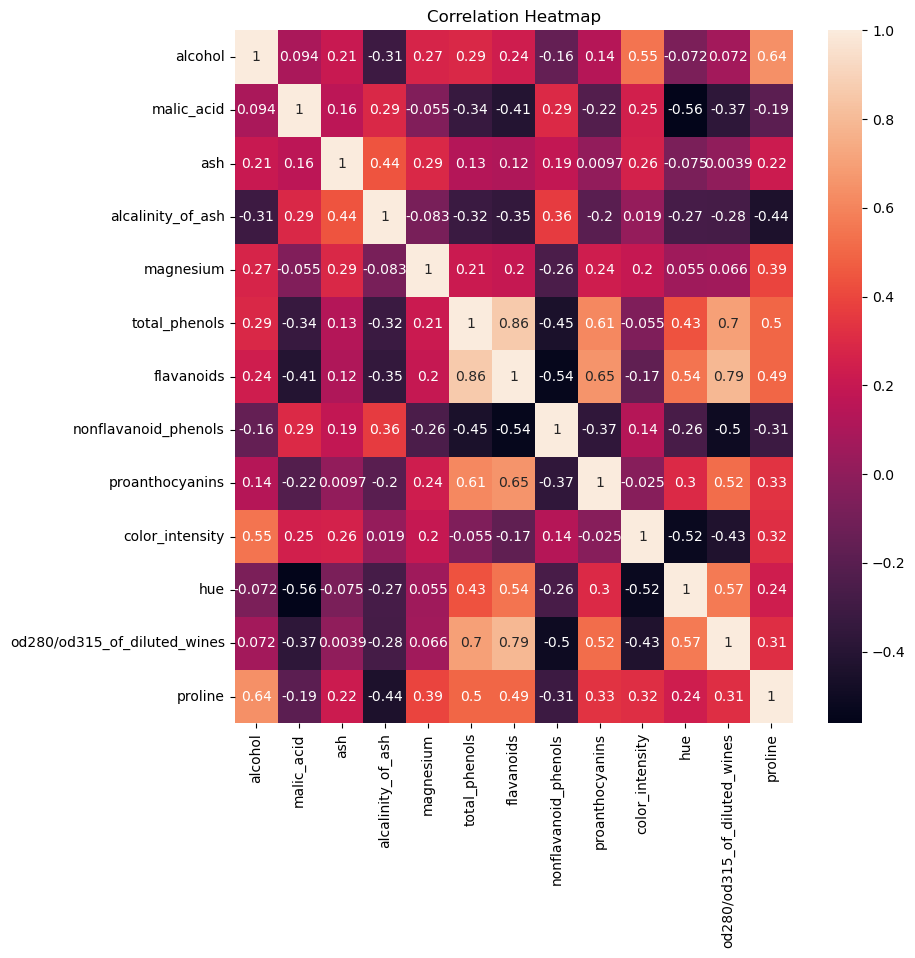

In [19]:
# correlation matrix for feature columns only
plt.figure(figsize=(9, 9))
sns.heatmap(df.drop(columns=["target"]).corr(), annot=True)
plt.title("Correlation Heatmap")
plt.show()

The Wine dataset's properties include a number of strong and moderate correlations, according to the correlation heatmap. Specifically, there is a very strong positive association between total phenols and flavanoids, and flavanoids also have strong correlations with proanthocyanins and od280/od315 of diluted wines. There are also negative relationships, such the one between hue and color intensity. These patterns verify the existence of redundancy in the dataset by showing that some features contain overlapping information. In order to reduce dimensionality while maintaining the most informative variance, this facilitates the usage of PCA in later parts.

# 5 Model Building and Evaluation

Using the Wine dataset, this part develops and assesses several machine learning models. The process divides the dataset into training and testing sets, applies feature scaling, trains models, and assesses performance using classification metrics in accordance with a typical supervised learning pipeline. Additionally, more accurate performance estimations are obtained through the use of cross-validation. k-Nearest Neighbors (kNN) is constructed from scratch using just Python and NumPy in order to fulfill the class requirement. Later, PCA is also used to investigate if dimensionality reduction affects model performance.

## 5.1 Train-test split

The dataset is divided into testing and training sets in this section. In order to maintain the class distribution in both sets and provide a fair assessment of classification models, a stratified split is used.

In [20]:
# Import the required library
from sklearn.model_selection import train_test_split

In [21]:
# target store in y
y = wine.target

In [22]:
# Train test split
X_train, X_test, y_train, y_test = train_test_split(X,y, test_size=0.20,stratify=y,random_state=42)

In [23]:
# Print the shapes
print("Xtrain:", X_train.shape)
print("Xtest:", X_test.shape)
print("ytrain:", y_train.shape)
print("ytest:", y_test.shape)

Xtrain: (142, 13)
Xtest: (36, 13)
ytrain: (142,)
ytest: (36,)


Stratification was used to divide the dataset into training and testing sets. In order to maintain realistic performance predictions, the test set will be retained for the final evaluation and the training set will be used to fit the models.

## 5.2 Feature Scaling

To ensure that all features have similar scales, this section uses StandardScaler to standardise the feature values. This is important for distance-based techniques like PCA and kNN, as both are sensitive to variations in feature magnitude.

In [24]:
# Import required library
from sklearn.preprocessing import StandardScaler
import numpy as np

In [25]:
# Standaard scaler
scaler = StandardScaler()

In [26]:
# Fit the scaler on the training data
X_train_scaling = scaler.fit_transform(X_train)

In [27]:
# Transform the test data
X_test_scaling = scaler.transform(X_test)

In [28]:
# Print Statements
print("Mean", np.mean(X_train_scaling, axis=0))
print("Standard Deviation", np.std(X_train_scaling, axis=0))

Mean [ 1.09781120e-15 -2.57227729e-16  9.52485352e-16  5.50127236e-16
  1.95461800e-17 -2.89283464e-16  2.00152883e-16 -9.71054223e-16
 -1.57933134e-16  4.45066519e-16 -9.34307405e-16  1.03047461e-15
 -2.07971355e-16]
Standard Deviation [1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1.]


To prevent data leaking, the features have been standardised using training-only fitting. For fair model training and evaluation, especially for kNN and PCA, the scaled training and test sets are now prepared.

# 5.3 KNN Build from Scratch

This section uses NumPy and Python alone to implement k-Nearest Neighbors (kNN) from scratch (Baliyan, M., 2020). Each test sample is classified by the model using majority voting to identify the k nearest training examples in feature space. The coursework requirement to implement a minimum of one machine learning algorithm without using machine learning libraries is fulfilled by this.

In [29]:
# Import the required libraries
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, ConfusionMatrixDisplay
from sklearn.base import BaseEstimator, ClassifierMixin
from sklearn.model_selection import learning_curve

In [30]:
# Calculate Euclidean distances (referenced code from Baliyan, M., 2020 to build own knn model)
def euclidean_distances(a, b):
    # squared norms of A (sum of squares per row)
    a_2 = np.sum(a ** 2, axis=1, keepdims=True)

    # squared norms of B (sum of squares per row), then transpose
    b_2 = np.sum(b ** 2, axis=1, keepdims=True).T 

    # Use the identity
    d_2 = a_2 + b_2 - 2 * (a @ b.T)

    # distance squared should not be negative and return
    d2 = np.maximum(d_2, 0.0)
    return np.sqrt(d2)

In [31]:
# KNN prediction (referenced code from Baliyan, M., 2020 to build own knn model)
def knnprediction(X_train, y_train, query_x, k=5):
    # Compute distances
    distance = euclidean_distances(query_x, X_train)

    # indixes of the k smallest distances
    k_smallest = np.argsort(distance, axis=1)[:, :k]

    # neighbour labels
    neighbour = y_train[k_smallest]

    # Majority vote for each query sample
    prediction = []
    for row in neighbour:
        # times each class appears
        count = np.bincount(row, minlength=np.max(y_train) + 1)

        # class with the highest count choose
        prediction.append(np.argmax(count))

    # Return predictions
    return np.array(prediction)

In [32]:
# Scratch knn function to use the scikit learn tools (referenced code from Baliyan, M., 2020 to build own knn model)
class scratchknn(BaseEstimator, ClassifierMixin):
    # k value 
    def __init__(self, k=5):
        self.k = k

    # Store the train data
    def fit(self, X, y):
        # feature matrix
        self.X_train_ = X
        # target
        self.y_train_ = y
        # class
        self.classes_ = np.unique(self.y_train_)
        return self

    def predict(self, X):
        # Predict using build knnprediction function
        return knnprediction(self.X_train_, self.y_train_, X, k=self.k)

Because scikit-learn requires models to implement the fit and predict methods for compatibility with functions like cross_val_score, we developed the scratchknn class. We wrapped the original KNN implementation in a class that enables me to efficiently use scikit-learn's tools without changing the fundamental KNN logic because it is not held to the scikit-learn API.

In [33]:
# Build and train the model
knn_model = scratchknn(k=5)
knn_model.fit(X_train_scaling, y_train)

,k,5


In [34]:
# Predict labels for the test set
ypredictknn = knn_model.predict(X_test_scaling)

In [35]:
# test set accuracy
accuracyknn = accuracy_score(y_test, ypredictknn)
print("Accuracy", accuracyknn)

Accuracy 0.9722222222222222


In [36]:
# Define class names from the Wine dataset
names_classwine = wine.target_names

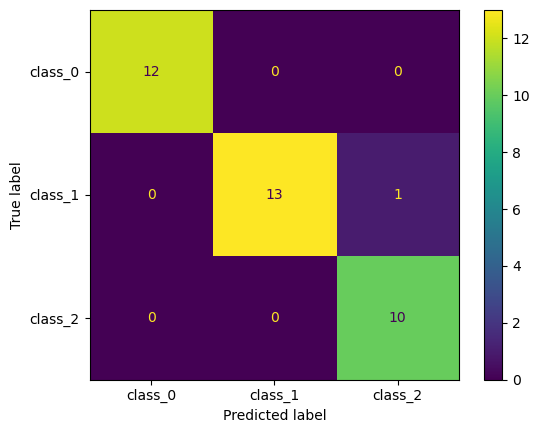

              precision    recall  f1-score   support

     class_0       1.00      1.00      1.00        12
     class_1       1.00      0.93      0.96        14
     class_2       0.91      1.00      0.95        10

    accuracy                           0.97        36
   macro avg       0.97      0.98      0.97        36
weighted avg       0.97      0.97      0.97        36



In [37]:
# confusion matrix for new kNN
cm = confusion_matrix(y_test, ypredictknn)
show = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=names_classwine)
show.plot()
plt.show()

# Classification report
print(classification_report(y_test, ypredictknn, target_names=names_classwine))

In [38]:
# To plot the learning cureve
train_sizes, trainscore, testscore = learning_curve(knn_model, X_train_scaling, y_train, cv=5, scoring='accuracy', n_jobs=-1,train_sizes=np.linspace(0.1, 1.0, 10))

In [39]:
# Calculate mean and standard deviation for train and test scores
meantrain = np.mean(trainscore, axis=1)
stdtrain = np.std(trainscore, axis=1)
meantest = np.mean(testscore, axis=1)
stdtest = np.std(testscore, axis=1)

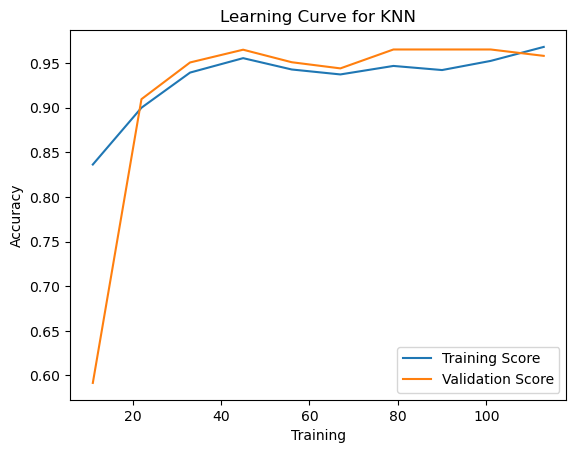

In [40]:
# Plot the learning curves
plt.plot(train_sizes, meantrain, label="Training Score")
plt.plot(train_sizes, meantest, label="Validation Score")
plt.title("Learning Curve for KNN")
plt.xlabel("Training")
plt.ylabel("Accuracy")
plt.legend()
plt.show()

With a test accuracy of 0.97, the scratch build kNN model demonstrated excellent classification performance on the Wine dataset. Class_0 and class_2 are perfectly classified in the confusion matrix, however class_1, which was classfied to be class_2, only had one misclassification. The classification report, which has a weighted F1-score of 0.97 and strong precision and recall values, further shows balanced performance across classes. These findings show that when features are appropriately scaled, kNN is quite effective for this dataset, offering a strong baseline for comparison with other machine learning models.

The kNN learning curve shows that the model rapidly achieves high accuracy as the size of the training set increases, suggesting good generalisation. The model appears to be neither overfitting nor underfitting and is operating consistently across a range of training sizes, as shown by the small difference between the training and validation scores.

## 5.4 Decision Tree Classifier

The Wine dataset is put through to a Decision Tree classifier in this part. By learning a set of recursive decision rules based on feature values, decision trees classify data. Decision Trees are less prone to feature scaling and do not rely on distance, in contrast to kNN. This model is used to contrast the previously used distance-based kNN classifier with a rule-based learning method.

In [41]:
# Import required library
from sklearn.tree import DecisionTreeClassifier

In [42]:
# Decision Tree classifier, to prevent overfitting max depth set to 5
decision_treemodel = DecisionTreeClassifier(random_state=42, max_depth=5)

In [43]:
# Train the Decision Tree model
decision_treemodel.fit(X_train_scaling, y_train)

,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.",'gini'
,"splitter splitter: {""best"", ""random""}, default=""best""The strategy used to choose the split at each node. Supportedstrategies are ""best"" to choose the best split and ""random"" to choosethe best random split.",'best'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",5
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: int, float or {""sqrt"", ""log2""}, default=NoneThe number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... note:: The search for a split does not stop until at least one valid partition of the node samples is found, even if it requires to effectively inspect more than ``max_features`` features.",None
,"random_state random_state: int, RandomState instance or None, default=NoneControls the randomness of the estimator. The features are alwaysrandomly permuted at each split, even if ``splitter`` is set to``""best""``. When ``max_features < n_features``, the algorithm willselect ``max_features`` at random at each split before finding the bestsplit among them. But the best found split may vary across differentruns, even if ``max_features=n_features``. That is the case, if theimprovement of the criterion is identical for several splits and onesplit has to be selected at random. To obtain a deterministic behaviourduring fitting, ``random_state`` has to be fixed to an integer.See :term:`Glossary ` for details.",42
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow a tree with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current no

In [44]:
# Predict class labels for the test set
ypredictiondecisiontree = decision_treemodel.predict(X_test_scaling)

In [45]:
# test accuracy
accuracy_decisiontree = accuracy_score(y_test, ypredictiondecisiontree)
print("Accuracy:", accuracy_decisiontree)

Accuracy: 0.9444444444444444


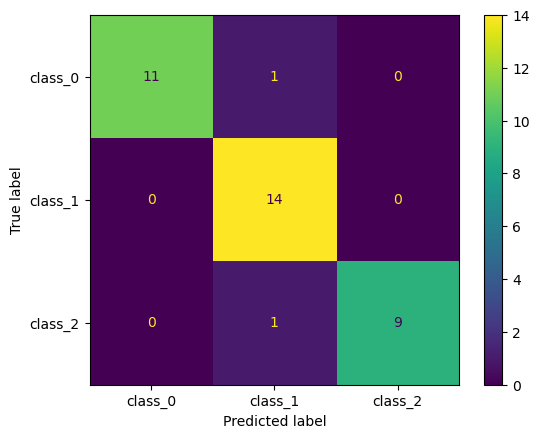

              precision    recall  f1-score   support

     class_0       1.00      0.92      0.96        12
     class_1       0.88      1.00      0.93        14
     class_2       1.00      0.90      0.95        10

    accuracy                           0.94        36
   macro avg       0.96      0.94      0.95        36
weighted avg       0.95      0.94      0.94        36



In [46]:
# confusion matrix for Decision Tree
cm = confusion_matrix(y_test, ypredictiondecisiontree)
show = ConfusionMatrixDisplay(confusion_matrix=cm,display_labels=names_classwine)
show.plot()
plt.show()

# classification report
print(classification_report(y_test, ypredictiondecisiontree, target_names=names_classwine))

In [47]:
# the learning cureve
train_sizes, trainscore, testscore = learning_curve(decision_treemodel, X_train_scaling, y_train, cv=5, scoring='accuracy', n_jobs=-1,train_sizes=np.linspace(0.1, 1.0, 10))

In [48]:
# mean and standard deviation for train and test scores
meantrain = np.mean(trainscore, axis=1)
stdtrain = np.std(trainscore, axis=1)
meantest = np.mean(testscore, axis=1)
stdtest = np.std(testscore, axis=1)

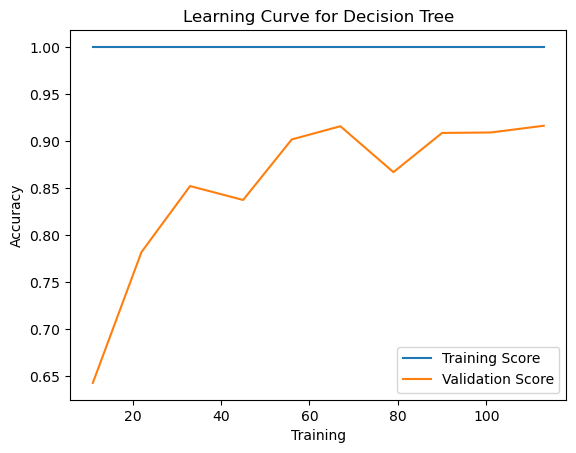

In [49]:
# Plot the learning curves
plt.plot(train_sizes, meantrain, label="Training Score")
plt.plot(train_sizes, meantest, label="Validation Score")
plt.title("Learning Curve for Decision Tree")
plt.xlabel("Training")
plt.ylabel("Accuracy")
plt.legend()
plt.show()

On the Wine dataset, the Decision Tree classifier obtained a test accuracy of 0.94. With only one misclassifications between class_0 and class_1 and between class_2 and class_1, the confusion matrix demonstrates that the majority of samples were correctly identified. Although overall performance is marginally worse than that of the kNN model, the classification report shows excellent precision and recall across all classes. This tells that, in comparison to the distance-based kNN technique, the Decision Tree may be more sensitive to small variations even while it captures significant decision boundaries in the data.

A high training score 1.0 indicates that the model fits the training data well, and the Decision Tree's learning curve demonstrates that the model significantly improves with more training data. Although there may still be some sensitivity to changes in the training data, as shown by the validation score's fluctuations, the validation score gradually rises and fluctuate, showing that the model is learning from the data without overfitting.

## 5.5 Gaussian Naive Bayes

The Wine dataset is used in this section to apply Gaussian Naive Bayes. The naive assumption of the Bayes theorem-based probabilistic classifier Naive Bayes is that features are conditionally independent given the class. Because it represents each feature as a normal distribution within each class, the Gaussian variant is appropriate for continuous numerical features. This model is used to evaluate a probabilistic method against the rule-based Decision Tree and the distance-based kNN.

In [50]:
# Import required library
from sklearn.naive_bayes import GaussianNB

In [51]:
# Gaussian Naive Bayes model
naive_model = GaussianNB()

In [52]:
# Train the naive model
naive_model.fit(X_train_scaling, y_train)

,"priors priors: array-like of shape (n_classes,), default=NonePrior probabilities of the classes. If specified, the priors are notadjusted according to the data.",None
,"var_smoothing var_smoothing: float, default=1e-9Portion of the largest variance of all features that is added tovariances for calculation stability... versionadded:: 0.20",1e-09


In [53]:
# Predict labels for test set
ypredictionnaive = naive_model.predict(X_test_scaling)

In [54]:
# test accuracy
accuracy_naive = accuracy_score(y_test, ypredictionnaive)
print("Accuracy:", accuracy_naive)

Accuracy: 0.9722222222222222


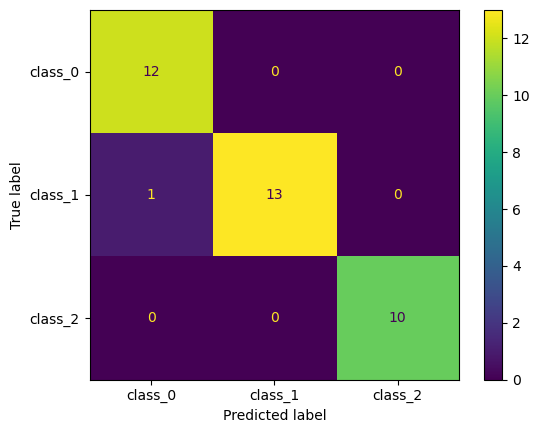

              precision    recall  f1-score   support

     class_0       0.92      1.00      0.96        12
     class_1       1.00      0.93      0.96        14
     class_2       1.00      1.00      1.00        10

    accuracy                           0.97        36
   macro avg       0.97      0.98      0.97        36
weighted avg       0.97      0.97      0.97        36



In [55]:
# confusion matrix for Gaussian Naive Bayes
cm = confusion_matrix(y_test, ypredictionnaive)
show = ConfusionMatrixDisplay(confusion_matrix=cm,display_labels=names_classwine)
show.plot()
plt.show()

# classification report
print(classification_report(y_test, ypredictionnaive, target_names=names_classwine))

In [56]:
# To plot the learning cureve
train_sizes, trainscore, testscore = learning_curve(naive_model, X_train_scaling, y_train, cv=5, scoring='accuracy', n_jobs=-1,train_sizes=np.linspace(0.1, 1.0, 10))

In [57]:
# mean and standard deviation for train and test scores
meantrain = np.mean(trainscore, axis=1)
stdtrain = np.std(trainscore, axis=1)
meantest = np.mean(testscore, axis=1)
stdtest = np.std(testscore, axis=1)

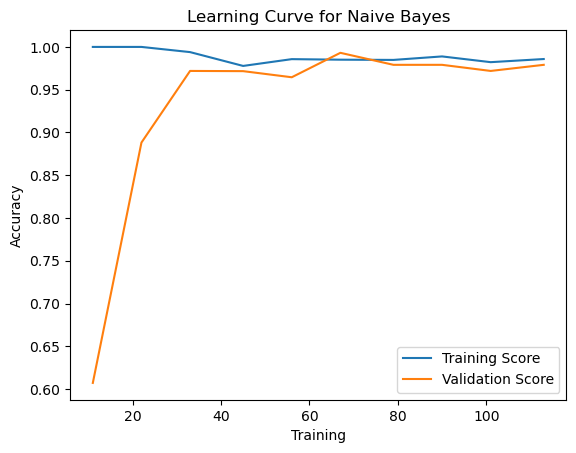

In [58]:
# Plot the learning curves
plt.plot(train_sizes, meantrain, label="Training Score")
plt.plot(train_sizes, meantest, label="Validation Score")
plt.title("Learning Curve for Naive Bayes")
plt.xlabel("Training")
plt.ylabel("Accuracy")
plt.legend()
plt.show()

On the Wine dataset, the Gaussian Naive Bayes classifier had a test accuracy of 0.97. Class_2 is perfectly classified in the confusion matrix, but class_0, which was supposed to be class_1, has only one misclassification. With a weighted F1-score of 0.97, the classification report shows excellent recall and precision in all classes. The Naive Bayes model performs competitively on this dataset, showing that the class-conditional feature distributions are sufficiently separable despite its simplifying independence assumption.

As the size of the training set grows, the Naive Bayes learning curve demonstrates that the model rapidly achieves high accuracy. Both the validation and training scores stabilise at high values, and they closely follow each other. This shows that there are no indications of overfitting and the model is well regularised. Even with larger training sets, the accuracy difference between training and validation is still small, indicating that the model performs well when applied to new data.

# 6 Cross-Validation

Cross-validation is used in this section to estimate model performance more accurately than a single train-test split. By repeating training and testing over several dataset folds, cross-validation reduces dependence on a single split and improves the stability of each model. To maintain a comparable class distribution across each fold, stratified k-fold cross-validation is used. Because it ensures that each fold has a balanced representation of the three classes, stratification is important.

In [59]:
# Import required library
from sklearn.model_selection import StratifiedKFold
from sklearn.model_selection import cross_val_score
from sklearn.pipeline import make_pipeline

In [60]:
# stratified k-fold object
crossvalidation = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

In [61]:
# models for validation
cross_validationmodels = {
    "kNN": make_pipeline(StandardScaler(), scratchknn(k=5)),
    "Decision Tree": DecisionTreeClassifier(random_state=42),
    "Gaussian Naive Bayes": make_pipeline(StandardScaler(), GaussianNB())
}

Five stratified folds and a consistent random seed have been used to set up cross-validation for reproducibility. For every model, cross-validation is then performed, and the mean accuracy and variability over folds are noted. Cross-validation is only applied to the training set. Only the final confirmation of the chosen model's performance on data that was not observed is provided by the held-out test set.

In [62]:
# list to store the results
cross_validationresults = []

In [63]:
# Each model compute cross-validation
for name, model in cross_validationmodels.items():
    results = cross_val_score(model, X_train, y_train, cv=crossvalidation, scoring="accuracy")
    
    # mean and standard deviation of the accuracy scores
    cross_validationresults.append({
        "Model": name,
        "Mean Accuracy": results.mean(),
        "Standard deviation": results.std(),
        "Fold Accuracies": results
    })

In [64]:
# Convert results to df
result_df = pd.DataFrame(cross_validationresults)

In [65]:
# results table
result_df[["Model", "Mean Accuracy", "Standard deviation"]].sort_values(by="Mean Accuracy",ascending=False)

,Model,Mean Accuracy,Standard deviation
2,Gaussian Naive Bayes,0.972167,0.025875
0,kNN,0.950739,0.035274
1,Decision Tree,0.902217,0.058617


In [66]:
# fold accuracy for each model
for row in cross_validationresults:
    print("Model:", row["Model"])
    print("Fold accuracies:", np.round(row["Fold Accuracies"], 2))
    print("Mean:", round(row["Mean Accuracy"], 2), "Std:", round(row["Standard deviation"], 2))

Model: kNN
Fold accuracies: [0.9  1.   0.96 0.93 0.96]
Mean: 0.95 Std: 0.04
Model: Decision Tree
Fold accuracies: [0.79 0.9  0.93 0.96 0.93]
Mean: 0.9 Std: 0.06
Model: Gaussian Naive Bayes
Fold accuracies: [0.93 0.97 1.   1.   0.96]
Mean: 0.97 Std: 0.03


The cross-validation data shows a clear difference in the average performance and stability of the three models. Gaussian Naive Bayes showed strong and consistent performance across folds, with the lowest standard deviation (0.03) and the best mean accuracy (0.97). The Decision Tree model's moderate mean accuracy (0.90) and slightly higher variability (0.06) show that it did quite well but was more sensitive to the training data. Additionally, the kNN model showed outstanding cross-validation performance with a high mean accuracy (0.95) and low variability (0.04), showing strong generalization across many splits. Overall, cross-validation shows that the most stable model for this dataset is Gaussian Naive Bayes, with Decision Tree showing the highest sensitivity to data change and kNN offering similar good performance.

# 7 PCA

In this part, the dimensionality of the Wine dataset is reduced using Principal Component Analysis (PCA). A smaller set of uncorrelated components that account for the majority of the data's variation is created by PCA from the original features. This section aims to assess whether dimensionality reduction improves or decreases classification performance, as well as how much variance can be maintained with fewer components.

## 7.1 PCA & Explained Variance

This section looks at how much variance is explained by each principal component after fitting PCA to the scaled training data. Finding the right number of components to keep while reducing information loss is made easier by analysing explained variance.

In [67]:
# Import required library
from sklearn.decomposition import PCA

In [68]:
# PCA object
pcachecking = PCA()

In [69]:
# train pca
pcachecking.fit(X_train_scaling)

,"n_components n_components: int, float or 'mle', default=NoneNumber of components to keep.if n_components is not set all components are kept:: n_components == min(n_samples, n_features)If ``n_components == 'mle'`` and ``svd_solver == 'full'``, Minka'sMLE is used to guess the dimension. Use of ``n_components == 'mle'``will interpret ``svd_solver == 'auto'`` as ``svd_solver == 'full'``.If ``0 < n_components < 1`` and ``svd_solver == 'full'``, select thenumber of components such that the amount of variance that needs to beexplained is greater than the percentage specified by n_components.If ``svd_solver == 'arpack'``, the number of components must bestrictly less than the minimum of n_features and n_samples.Hence, the None case results in:: n_components == min(n_samples, n_features) - 1",None
,"copy copy: bool, default=TrueIf False, data passed to fit are overwritten and runningfit(X).transform(X) will not yield the expected results,use fit_transform(X) instead.",True
,"whiten whiten: bool, default=FalseWhen True (False by default) the `components_` vectors are multipliedby the square root of n_samples and then divided by the singular valuesto ensure uncorrelated outputs with unit component-wise variances.Whitening will remove some information from the transformed signal(the relative variance scales of the components) but can sometimeimprove the predictive accuracy of the downstream estimators bymaking their data respect some hard-wired assumptions.",False
,"svd_solver svd_solver: {'auto', 'full', 'covariance_eigh', 'arpack', 'randomized'}, default='auto'""auto"" : The solver is selected by a default 'auto' policy is based on `X.shape` and `n_components`: if the input data has fewer than 1000 features and more than 10 times as many samples, then the ""covariance_eigh"" solver is used. Otherwise, if the input data is larger than 500x500 and the number of components to extract is lower than 80% of the smallest dimension of the data, then the more efficient ""randomized"" method is selected. Otherwise the exact ""full"" SVD is computed and optionally truncated afterwards.""full"" : Run exact full SVD calling the standard LAPACK solver via `scipy.linalg.svd` and select the components by postprocessing""covariance_eigh"" : Precompute the covariance matrix (on centered data), run a classical eigenvalue decomposition on the covariance matrix typically using LAPACK and select the components by postprocessing. This solver is very efficient for n_samples >> n_features and small n_features. It is, however, not tractable otherwise for large n_features (large memory footprint required to materialize the covariance matrix). Also note that compared to the ""full"" solver, this solver effectively doubles the condition number and is therefore less numerical stable (e.g. on input data with a large range of singular values).""arpack"" : Run SVD truncated to `n_components` calling ARPACK solver via `scipy.sparse.linalg.svds`. It requires strictly `0 < n_components < min(X.shape)`""randomized"" : Run randomized SVD by the method of Halko et al... versionadded:: 0.18.0.. versionchanged:: 1.5 Added the 'covariance_eigh' solver.",'auto'
,"tol tol: float, default=0.0Tolerance for singular values computed by svd_solver == 'arpack'.Must be of range [0.0, infinity)... versionadded:: 0.18.0",0.0
,"iterated_power iterated_power: int or 'auto', default='auto'Number of iterations for the power method computed bysvd_solver == 'randomized'.Must be of range [0, infinity)... versionadded:: 0.18.0",'auto'
,"n_oversamples n_oversamples: int, default=10This parameter is only relevant when `svd_solver=""randomized""`.It corresponds to the additional number of random vectors to sample therange of `X` so as to ensure proper conditioning. See:func:`~sklearn.utils.extmath.randomized_svd` for more details... versionadded:: 1.1",10
,"power_iteration_normalizer power_iteration_normalizer: {'auto', 'QR', 'LU', 'none'}, default='auto'Power iteration normalizer for randomized S

In [70]:
# explained variance ratio for each component
explainevariance = pcachecking.explained_variance_ratio_

In [71]:
# Print explained variance for each component
for i, var in enumerate(explainevariance, start=1):
    print(f"pca {i}: {var:.4f}")

pca 1: 0.3579
pca 2: 0.1927
pca 3: 0.1102
pca 4: 0.0727
pca 5: 0.0672
pca 6: 0.0513
pca 7: 0.0438
pca 8: 0.0250
pca 9: 0.0228
pca 10: 0.0188
pca 11: 0.0178
pca 12: 0.0126
pca 13: 0.0072


In [72]:
# cumulative explained variance
print("Cumulative explained variance:", np.cumsum(explainevariance))

Cumulative explained variance: [0.35792104 0.55062776 0.66082611 0.73354887 0.80076806 0.85208748
 0.89586171 0.92087024 0.94366454 0.96243556 0.98025321 0.99282042
 1.        ]


The explained variance values indicate the amount of information that each principle component extracts from the original dataset. The cumulative explained variance helps in determining the number of components needed to reduce dimensionality while maintaining the majority of the original data. According to the explained variance results, roughly 35.8% of the total variance is captured by the first main component, and roughly 55.1% is captured by the first two components combined. This shows that, although retaining only half of the overall variance therefore having some information loss, using two components offers a compact representation of the data for the PCA experiment.

## 7.2 PCA Cumulative Explained Variance Plot

The cumulative explained variance is shown against the number of major components in this section. This graph helps determine how many components should be kept for further research.

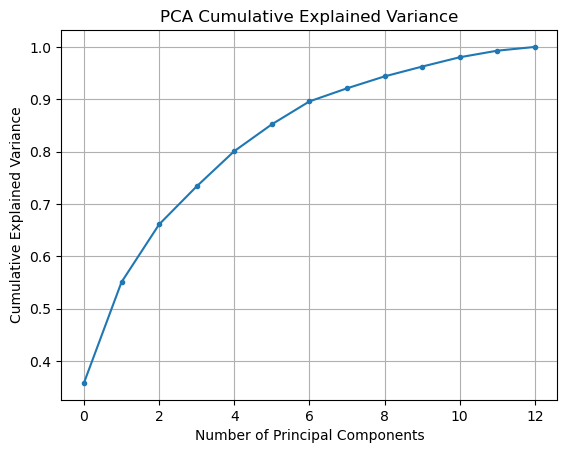

In [73]:
# sum of explained variance
plt.plot(np.cumsum(explainevariance),marker=".")
plt.xlabel("Number of Principal Components")
plt.ylabel("Cumulative Explained Variance")
plt.title("PCA Cumulative Explained Variance")
plt.grid(True)
plt.show()

With five components, the cumulative explained variance rises steadily to about 80%, and with eight components, it surpasses 90%. This suggests that associated features in the dataset share a substantial amount of information. Strong dimensionality reduction is achieved by using just two components, which comes at the expense of some information loss in exchange for better interpretability and computational ease.

## 7.3 Dimensionality Reduction

This section uses PCA with a fixed number of components based on the explained variance analysis. Classifiers will be trained and assessed using the converted data, enabling direct comparison with outcomes from the full feature set.

In [74]:
# pca object
pcachecking = PCA(n_components=2)

In [75]:
# Fit PCA scale train data transform scale test data
X_train_pca = pcachecking.fit_transform(X_train_scaling)
X_test_pca = pcachecking.transform(X_test_scaling)

In [76]:
# shapes dimensionality reduction
print("Original shape:", X_train_scaling.shape)
print("PCA-reduced shape:", X_train_pca.shape)

Original shape: (142, 13)
PCA-reduced shape: (142, 2)


The training data was reduced from 13 original features to 2 principle components after two-component PCA was used, while maintaining more than half of the dataset's overall variance. This shows that PCA effectively removes duplication and compresses the feature space, creating a lower-dimensional representation appropriate for assessing how dimensionality reduction affects model performance.

## 7.4 Model Evaluation PCA Reduced Data

Using PCA-transformed features, the same classifiers are assessed in this section. These findings can be compared to previous model performance to determine whether dimensionality reduction enhances generalisation or results in information loss.

In [77]:
#  knn model on new pca data
knn_pca = scratchknn(k=5)
knn_pca.fit(X_train_pca, y_train)
y_prediction_knn = knn_pca.predict(X_test_pca)
acc_knn = accuracy_score(y_test, y_prediction_knn)
print("kNN:", acc_knn)

kNN: 0.9166666666666666


In [78]:
# decision tree model on new pca data
decision_treepca = DecisionTreeClassifier(random_state=42)
decision_treepca.fit(X_train_pca, y_train)
y_pred_decisiontreee_pca = decision_treepca.predict(X_test_pca)
accuracy_deicisontree = accuracy_score(y_test, y_pred_decisiontreee_pca)
print("Decision Tree:", accuracy_deicisontree)

Decision Tree: 0.8888888888888888


In [79]:
# Gaussian Naive Bayes on new pca data
naive_pca = GaussianNB()
naive_pca.fit(X_train_pca, y_train)
y_predtion_naivepca = naive_pca.predict(X_test_pca)
acccuracy_naive = accuracy_score(y_test, y_predtion_naivepca)
print("Gaussian Naive Bayes:", acccuracy_naive)

Gaussian Naive Bayes: 0.9444444444444444


All three models showed some performance differences when trained on PCA-reduced features as opposed to the complete feature set. Despite dimensionality reduction, the kNN model maintains good performance, as shown by its accuracy of 0.92. The Decision Tree's accuracy of 0.89 indicates a slight decrease, perhaps as a result of feature information loss. Even after PCA, the Gaussian Naive Bayes model continued to be the best performer, with an accuracy of 0.94. These findings shows that although PCA increases interpretability and decreases dimensionality, its effect on performance varies depending on each model's learning assumptions, with predictive models showing higher stability.

# 8 Evaluation

<table border="1" style="border-collapse: collapse; width: 100%; text-align: center;">
  <thead>
    <tr>
      <th>Model</th>
      <th>Original Accuracy</th>
      <th>PCA Accuracy</th>
      <th>Cross-validation Mean</th>
      <th>Cross-validation std</th>
    </tr>
  </thead>
  <tbody>
    <tr>
      <td style="text-align:left;">kNN</td>
      <td>0.97</td>
      <td>0.92</td>
      <td>0.95</td>
      <td>0.04</td>
    </tr>
    <tr>
      <td style="text-align:left;">Decision Tree</td>
      <td>0.94</td>
      <td>0.89</td>
      <td>0.90</td>
      <td>0.06</td>
    </tr>
    <tr>
      <td style="text-align:left;">Gaussian Naive Bayes</td>
      <td>0.97</td>
      <td>0.94</td>
      <td>0.97</td>
      <td>0.03</td>
    </tr>
  </tbody>
</table>

The evaluation results show clear differences in the models' performance across different evaluation techniques. The model's sensitivity to data splits was highlighted by cross-validation results, but after applying consistent scaling within cross-validation, kNN shows strong average performance with low variability, which aligns more closely with its strong accuracy on a single train-test split. Because kNN is a distance-based model that is heavily influenced by individual data points and their closeness to one another, it is expected to show this behaviour and to depend strongly on preprocessing such as standardisation. The model's performance across various data splits is demonstrated by the cross-validation mean of 0.95 and the relatively low variability 0.04 in standard deviation, suggesting that kNN generalises well when evaluated under repeated resampling.

Decision trees may become unstable when the training data is changed, as seen by their uneven performance across different data splits. When improperly regularised, decision trees hierarchical models based on recursive partitioning may capture noise or irrelevant patterns in the data, which can lead to overfitting. The decision tree model demonstrated a slight decline in performance as a result of dimensionality reduction, achieving an accuracy of 0.94 on the original dataset and 0.89 using PCA. With a mean of 0.90 and a standard deviation of 0.06, the cross-validation results indicate that the model maintains respectable generalisation over several folds despite the occasional instability.

On the other hand, Gaussian Naive Bayes demonstrated great generalisation across cross-validation and PCA-based assessments, consistently achieving high accuracy with minimal variability. This is explained by the probabilistic character of the model, which assumes conditional independence across features and makes it more resistant to overfitting and better able to generalise to new data. The Gaussian Naive Bayes model's resilience to dimensionality reduction was demonstrated by the fact that its performance remained high after PCA, with accuracy changing from 0.97 on the original data to 0.94 on PCA-transformed data. With a cross-validation mean of 0.97 and a standard deviation of 0.03, the Naive Bayes model showed better consistency and stability over several folds.

These findings show how the underlying assumptions of each model cause it to act differently. Gaussian Naive Bayes, with its probabilistic nature, is the most stable and resistant to overfitting, maintaining high generalisation even under dimensionality reduction. kNN achieves strong performance when scaling is handled correctly, while Decision Trees need regularisation to prevent overfitting and can become unstable when data changes.

# 9 Conclusion

This project investigated the impact of PCA on classification performance and evaluated various supervised learning methods on the Wine dataset. The outcomes of a kNN classifier that was created from scratch were contrasted with those of Decision Tree and Gaussian Naive Bayes models. In general, Gaussian Naive Bayes performed the best consistently and robustly under various evaluation conditions. The dataset can be represented in a lower-dimensional space while keeping the much of its predictive information, according to PCA analysis. The use of dimensionality reduction methods and probabilistic models for this dataset is supported by these results.

# 10 References

scikit-learn (2024) Wine recognition dataset. (Online) Available at: https://scikit-learn.org/stable/modules/generated/sklearn.datasets.load_wine.html (Accessed on : 22nd December 2025).

Jiang, L. (2024) Research on Wine Classification Based on BP Neural Network. (Online)
Available at: https://www.researchgate.net/publication/383375490_Research_on_Wine_Classification_Based_on_BP_Neural_Network 
(Accessed on: 22nd December 2025).

Khilari, P., Patil, S., Pawar, A. and Jadhav, R. (2022) Analysis of Machine Learning Algorithms to Predict Wine Quality. (Online) Available at: https://www.researchgate.net/publication/360456284_Analysis_of_Machine_Learning_Algorithm_to_predict_Wine_Quality 
(Accessed on: 22nd December 2025).

Pradhana, A.A., Batubulan, K.S. and Kotama, I.W. (2024) Analysis of K-Nearest Neighbour Algorithm for Wine Quality Classification. (Online) Available at: https://infoteks.org/journals/index.php/jsikti/article/view/231 
(Accessed on: 22nd December 2025).

Cao, Y., Chen, H. and Lin, B. (2022) Wine Type Classification Using Random Forest Model. (Online) Available at: https://www.researchgate.net/publication/362436263_Wine_Type_Classification_Using_Random_Forest_Model  (Accessed on: 22nd December 2025).
Abhinav (2025) ‘Gini Impurity and Entropy in Decision Tree’, (Online) Available at: https://www.geeksforgeeks.org/machine-learning/gini-impurity-and-entropy-in-decision-tree-ml/ (Accessed: 25th December 2025).

Neha (2025) ‘Bayes’ Theorem’, (Online). Available at: https://www.geeksforgeeks.org/maths/bayes-theorem/ (Accessed: 25th December 2025).

Baliyan, M. (2020) ‘Implementation of K Nearest Neighbors from Scratch using Python’ (Online). Available at: https://www.geeksforgeeks.org/machine-learning/implementation-of-k-nearest-neighbors-from-scratch-using-python/ (Accessed: 25th December 2025).